# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt# importar librerías

In [55]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")#completa el código
usage = pd.read_csv("/datasets/usage.csv")#completa el código

In [56]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [57]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [58]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [59]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [60]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [61]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [62]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [63]:
# cantidad de nulos para users

print("\n>> users:")
print(users.isna().sum())# Cantidad de valores nulos)
print("\n>> users:")
print((users.isna().mean() * 100).round(2).astype(str) + '%')# Proporción de valores nulos)


>> users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

>> users:
user_id         0.0%
first_name      0.0%
last_name       0.0%
age             0.0%
city          11.72%
reg_date        0.0%
plan            0.0%
churn_date    88.35%
dtype: object


In [64]:
print(usage.isna().sum())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


In [65]:
print((usage.isna().mean() * 100).round(2).astype(str) + '%')

id            0.0%
user_id       0.0%
type          0.0%
date         0.12%
duration    55.19%
length      44.74%
dtype: object


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [66]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [67]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas id y user_id son consecutivas y de dato numerico

In [68]:
# explorar columnas categóricas de users
print("Distribución de city:")
print(users['city'].value_counts())
print("\nDistribución de plan:")
print(users['plan'].value_counts())


Distribución de city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Distribución de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` city tiene valores sucios (?, GDL vs nombre completo) 

- La columna `plan` plan tiene 2 categorías (Basico/Premium)

In [69]:



# explorar columna categórica de usage
 # completa el código
usage['type'].value_counts()




text    22092
call    17908
Name: type, dtype: int64

- La columna `type` se divide en text y call


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [70]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =  pd.to_datetime(users['reg_date'], errors='coerce')# completa el código

In [71]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [72]:

print("=== Años en reg_date (users) ===")
print(users['reg_date'].dt.year.value_counts().sort_index())# Revisar los años presentes en `reg_date` de users



=== Años en reg_date (users) ===
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [73]:

print("\n=== Años en date (usage) ===")
print(usage['date'].dt.year.value_counts().sort_index())
# Revisar los años presentes en `date` de usage




=== Años en date (usage) ===
2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

In [74]:
✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

SyntaxError: invalid character '✍' (U+270D) (1202541964.py, line 1)

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [75]:
# Reemplazar -999 por la mediana de age
age_mediana =users.loc[users['age'] != -999, 'age'].median() 
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print("=== age después de limpiar ===")
users['age'].describe()

=== age después de limpiar ===


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [76]:


users['city'] = users['city'].replace('?', pd.NA)
print("\n=== city después de limpiar ===")
print(users['city'].value_counts(dropna=False))# Reemplazar ? por NA en city



# Verificar cambios




=== city después de limpiar ===
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [77]:

mask = (users['reg_date'].dt.year > 2024) | (users['reg_date'].dt.year < 2000)
users.loc[mask, 'reg_date'] = pd.NaT
print("\n=== reg_date años después de limpiar ===")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())# Marcar fechas futuras como NA para reg_date


# Verificar cambios




=== reg_date años después de limpiar ===
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [78]:
# Verificación MAR en usage (Missing At Random) para duration
# Verificación MAR en usage (Missing At Random) para duration
print("=== Análisis de nulos en duration por type ===")
duration_analysis = pd.crosstab(usage['type'], usage['duration'].isna(), margins=True)
print(duration_analysis)
print("\nPorcentajes:")
print(pd.crosstab(usage['type'], usage['duration'].isna(), normalize='index') * 100)

=== Análisis de nulos en duration por type ===
duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000

Porcentajes:
duration       False      True 
type                           
call      100.000000   0.000000
text        0.072424  99.927576


In [79]:
# Verificación MAR en usage (Missing At Random) para length
# Verificación MAR en usage (Missing At Random) para length  
print("\n=== Análisis de nulos en length por type ===")
length_analysis = pd.crosstab(usage['type'], usage['length'].isna(), margins=True)
print(length_analysis)
print("\nPorcentajes:")
print(pd.crosstab(usage['type'], usage['length'].isna(), normalize='index') * 100)


=== Análisis de nulos en length por type ===
length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000

Porcentajes:
length       False      True 
type                         
call      0.067009  99.932991
text    100.000000   0.000000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` 
El diagnósticoLos datos son MAR porque la ausencia de la duración no es aleatoria en todo el dataset, sino que depende totalmente de otra variable visible: el type.En call (llamada): No falta casi nada ($0\%$). El sistema registra la duración siempre.En text (mensaje): Falta el $99.92\%$.

La falta de datos en length no es un error aleatorio del sistema, sino que está condicionada por la variable type.
Si es text: Tienes el dato de longitud en el 100% de los casos.
Si es call: El dato falta en el 99.93% de los casos.

**Decisión:** Mantener estos nulos como están porque representan la estructura lógica del negocio. Imputar estos valores sería incorrecto y distorsionaría el análisis posterior.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [80]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(5)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [81]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [82]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [83]:
user_profile.describe()# Resumen estadístico de las columnas numéricas


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [84]:
user_profile['plan'].value_counts(normalize=True) * 100 # Distribución porcentual del tipo de plan


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

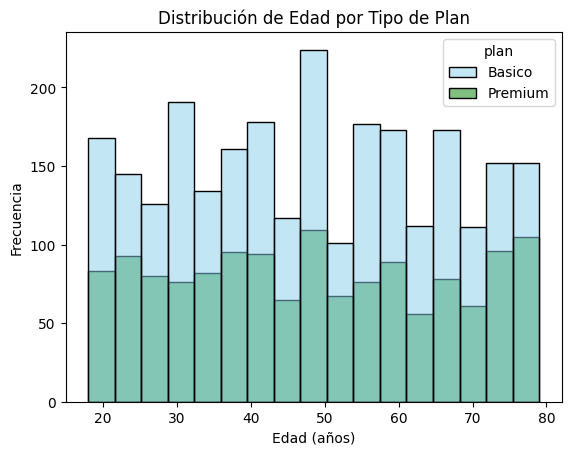

In [85]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...

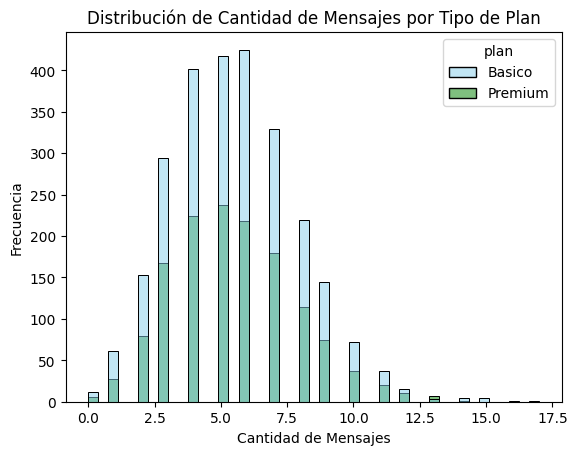

In [86]:

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_mensajes



💡Insights: 
- ....

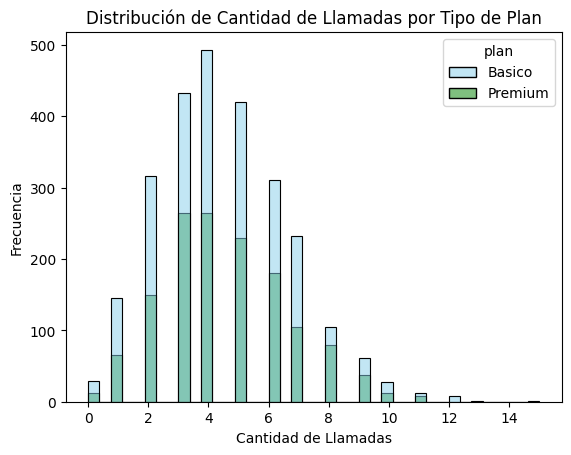

In [87]:
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_llamadas


💡Insights: 
- Distribución ...

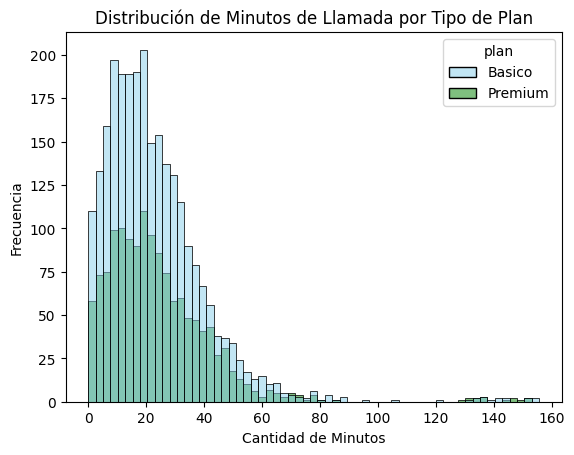

In [88]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Cantidad de Minutos')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_minutos_llamada


💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

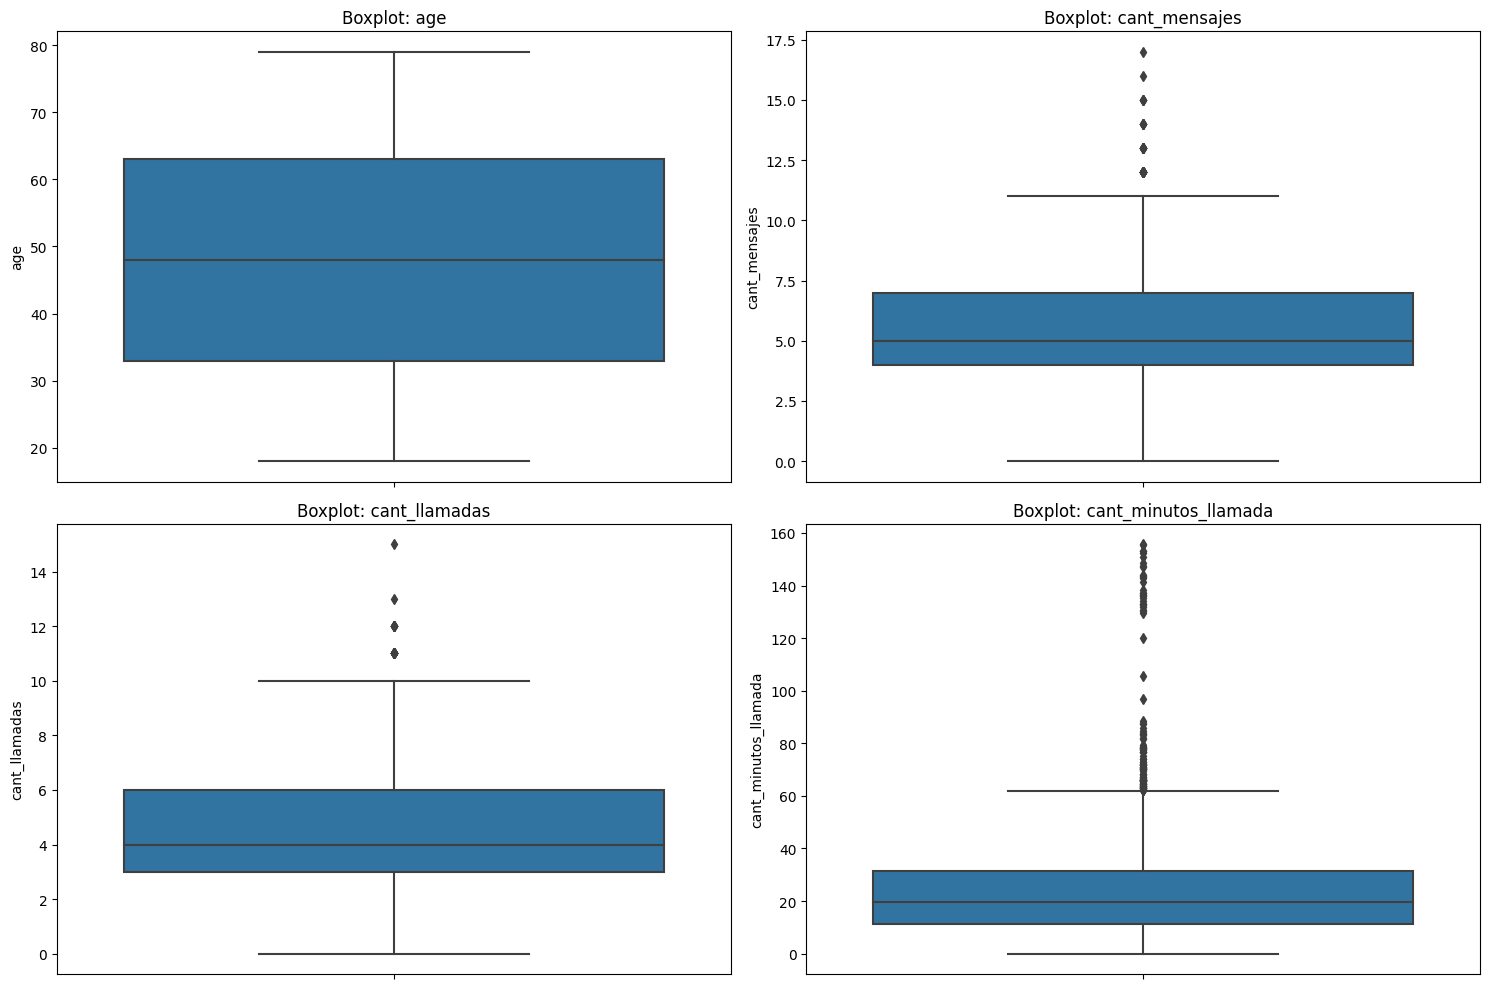

In [90]:
# Visualizando usando BoxPlot 
cols_to_check = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta 46 outliers 
- cant_llamadas:presenta 30 outliers 
- cant_minutos_llamada:presenta 109 outliers

In [91]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']



In [92]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? mantener los outliars por que son valores reales 
- cant_llamadas: mantener o no outliers, porqué? mantener los outliars por que son valores reales
- cant_minutos_llamada: mantener o no outliers, porqué? El valor de 155 minutos es bastante alto comparado con la media de 23.Pero si la predicción es sensible a valores extremos, podrías imputar los valores por encima de 61.85 al valor del límite superior para suavizar la curva, pero no borrarlos, ya que representan a clientes de alto valor.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [96]:
# 1. Primero asignamos el caso por defecto a todos ('Alto uso')
user_profile['grupo_uso'] = 'Alto uso'

# 2. Aplicamos la condición para 'Uso medio' 
# (llamadas < 10 y mensajes < 10)
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'

# 3. Aplicamos la condición para 'Bajo uso'
# (llamadas < 5 y mensajes < 5)
# Lo hacemos al final para que los que cumplen esta también, queden como 'Bajo uso'
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

# Verificamos los resultados
print(user_profile['grupo_uso'].value_counts())# Crear columna grupo_uso


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [97]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [98]:
# 1. Asignamos la categoría por defecto (el resto de casos)
user_profile['grupo_edad'] = 'Adulto Mayor'

# 2. Clasificamos a los 'Adultos' (menores a 60)
# Esto sobreescribirá a todos los que tengan menos de 60
user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'

# 3. Clasificamos a los 'Jóvenes' (menores a 30)
# Al ser el último paso, garantizamos que los menores de 30 
# queden como 'Joven' y no como 'Adulto'
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

# Verificamos cuántos usuarios hay en cada etapa de la vida
print(user_profile['grupo_edad'].value_counts())# Crear columna grupo_edad


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [99]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

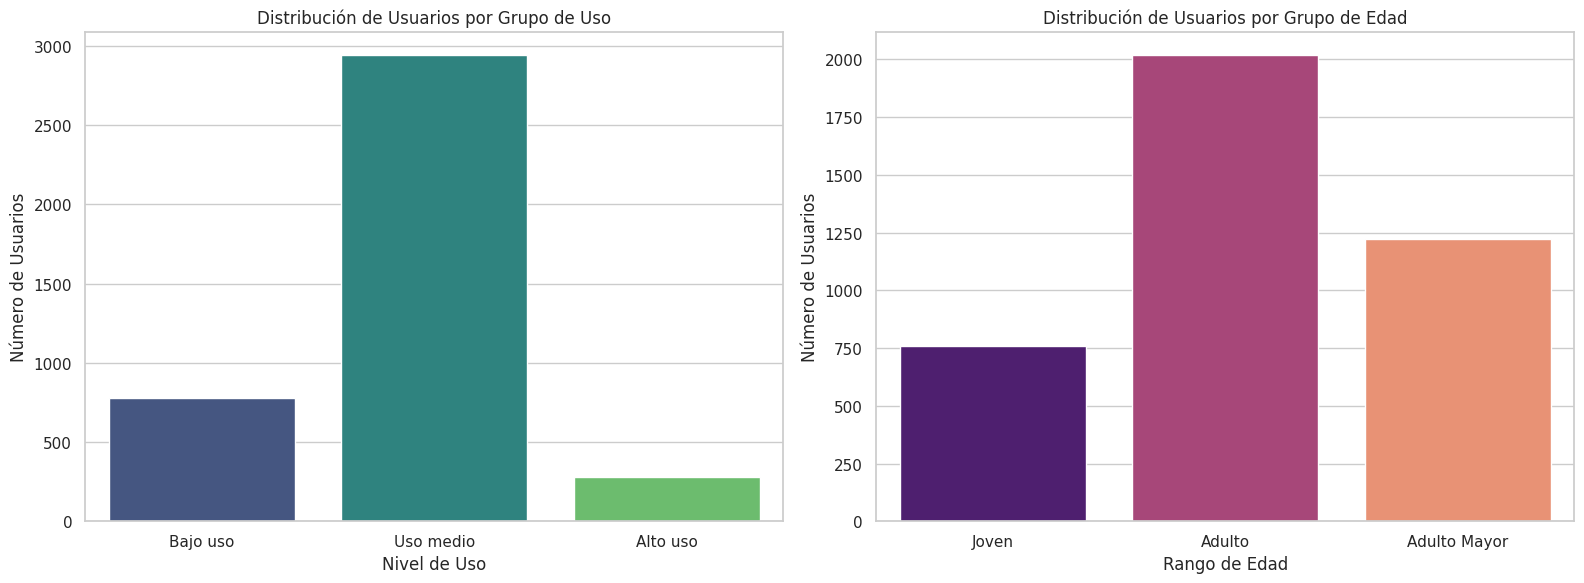

In [102]:
# Visualización de los segmentos por uso
# Crear una figura con dos subtramas (una al lado de la otra)
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Crear una figura con dos subtramas (una al lado de la otra)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico para grupo_uso
sns.countplot(data=user_profile, x='grupo_uso', ax=axes[0], palette='viridis', 
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
axes[0].set_title('Distribución de Usuarios por Grupo de Uso')
axes[0].set_xlabel('Nivel de Uso')
axes[0].set_ylabel('Número de Usuarios')

# 2. Gráfico para grupo_edad
sns.countplot(data=user_profile, x='grupo_edad', ax=axes[1], palette='magma',
              order=['Joven', 'Adulto', 'Adulto Mayor'])
axes[1].set_title('Distribución de Usuarios por Grupo de Edad')
axes[1].set_xlabel('Rango de Edad')
axes[1].set_ylabel('Número de Usuarios')

plt.tight_layout()
plt.show()

In [103]:
pd.crosstab(user_profile['grupo_uso'], user_profile['plan'], normalize='index') * 100

plan,Basico,Premium
grupo_uso,,
Alto uso,66.666667,33.333333
Bajo uso,65.809769,34.190231
Uso medio,64.458036,35.541964


In [104]:
# Ingresos promedio por segmento (si combinas con datos de planes)
user_profile.groupby('grupo_uso')['cant_minutos_llamada'].mean()

grupo_uso
Alto uso     30.149784
Bajo uso     14.919666
Uso medio    24.891526
Name: cant_minutos_llamada, dtype: float64


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Dataset users (4,000 filas):

city: 565 filas con valor "?" → 14.1% del total. Se reemplazaron con NaN.
age: valores sentinel de -999 → se reemplazaron con la mediana (48 años).
reg_date: 40 fechas en año 2026 (futuro) → 1% del total. Se marcaron como NaT.

Dataset usage (40,000 filas):

duration: 22,076 nulos → 55.19%. No es un error — los mensajes de texto no tienen duración. Son nulos estructurales (MAR).
length: 17,896 nulos → 44.74%. Mismo caso: las llamadas no tienen longitud de texto. También MAR.
date: 50 nulos → 0.12%. Mínimo impacto.




🔍 **Segmentos por Edad**
Por edad:
Segmento Usuarios 
Adulto (30–59 años)2,01850.5
Adulto Mayor (60+)1,22230.6
Joven (<30 años)76019.0



📊 **Segmentos por Nivel de Uso**
Por nivel de uso:
Segmento Usuarios Minutos promedio
Uso medio 2,943 (73.6%)24.9min
Bajo uso  778  (19.5%)14.9min
Alto uso  279  (7.0%)30.1 min

➡️ Esto sugiere que ...
 Segmentos más valiosos
Alto uso (279 usuarios) es el segmento más valioso porque:

Consumen 30 minutos promedio de llamadas, el doble que los de bajo uso.
Son candidatos directos a planes Premium o paquetes adicionales.
Aunque son solo el 7%, generan mayor ingreso por usuario.

Adulto Mayor también es interesante: representan el 30.6% y probablemente usan más llamadas que mensajes, lo que los hace candidatos a planes enfocados en minutos.
Curiosamente, la distribución de planes es casi igual entre segmentos (~65% Básico / ~35% Premium), lo que sugiere que el plan asignado no refleja bien el comportamiento real de uso.

📊 Outliers encontrados
Columna              Outliers                          Decisión 
age                    Ninguno                            —
cant_mensajes          46                             Conservar — valores reales
cant_llamadas          30                             Conservar — valores reales 
cant_minutos_llamada   109                            Conservar con precaución — máx 155 min vs media de 23 min
Los outliers en minutos son llamadas excepcionalmente largas. No son errores, pero sí representan usuarios con comportamiento atípico que podrían beneficiarse de un plan ilimitado o corporativo.

💡 **Recomendaciones**
💡 Recomendaciones para ConnectaTel

Crear un plan intermedio entre Básico (100 min) y Premium (600 min) — el segmento de "Uso medio" con ~25 minutos promedio está sobredimensionado en Premium y subdimensionado en Básico.
Migrar activamente a usuarios de Alto uso al plan Premium — el 66% de ellos aún está en plan Básico, lo que implica pérdida de ingresos.
Diseñar un plan para Adulto Mayor orientado a llamadas, con pocos mensajes y precio accesible — es el segundo segmento más grande.
Revisar el proceso de captura de datos — el 14% de ciudades inválidas y el 1% de fechas futuras indican problemas en el formulario de registro que afectan la calidad del CRM.
 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`